In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models for classification/regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor

from sklearn.metrics import accuracy_score, f1_score, classification_report, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import joblib

os.makedirs('models', exist_ok=True)  # Ensure models directory exists

# Load dataset
df = pd.read_csv(r'C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\Final_Nutrition_Dataset.csv')


In [6]:
# === Prepare features and multi-label targets ===
input_features = [
    'Age','Gender','Height_(cm)','Weight_(kg)','BMI','Daily_Calorie_Intake','Daily_Protein_Intake_(g)',
    'Daily_Fat_Intake_(g)','Daily_Carbohydrate_Intake_(g)','Daily_Fiber_Intake_(g)','Daily_Water_Intake_(liters)',
    'Vitamin_A_Intake_(mcg)','Vitamin_B1_(Thiamine)_Intake_(mg)','Vitamin_B2_(Riboflavin)_Intake_(mg)',
    'Vitamin_B3_(Niacin)_Intake_(mg)','Vitamin_B5_(Pantothenic_Acid)_Intake_(mg)','Vitamin_B6_Intake_(mg)',
    'Vitamin_B12_Intake_(mcg)','Vitamin_C_Intake_(mg)','Vitamin_D_Intake_(IU)','Vitamin_E_Intake_(mg)',
    'Vitamin_K_Intake_(mcg)','Iron_Intake_(mg)','Zinc_Intake_(mg)','Magnesium_Intake_(mg)',
    'Calcium_Intake_(mg)','Iodine_Intake_(mcg)','Selenium_Intake_(mcg)','Copper_Intake_(mg)','Folate_(Folic_Acid)_Intake_(mcg)','Phosphorus_Intake_(mg)','Manganese_Intake_(mg)','Chromium_Intake_(mcg)'
]

target_cols = [col for col in df.columns if col.endswith('_Deficiency')]

# Encode Gender if needed
df['Gender'] = LabelEncoder().fit_transform(df['Gender'].astype(str))

X = df[input_features]
y = df[target_cols]

# Scale features (optional but recommended)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[input_features] = scaler.fit_transform(X_scaled[input_features])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# === Detect and exclude zero-variance targets ===
valid_targets = []
excluded_targets = []

for col in y_train.columns:
    unique_vals = y_train[col].unique()
    if len(unique_vals) < 2:
        excluded_targets.append(col)
    else:
        valid_targets.append(col)

print(f"Excluded {len(excluded_targets)} constant targets:", excluded_targets)
print(f"Modeling {len(valid_targets)} variable targets.")

# Subset valid target columns for training
y_train_valid = y_train[valid_targets]
y_test_valid = y_test[valid_targets]

Excluded 1 constant targets: ['Daily_Carbohydrate_Deficiency']
Modeling 26 variable targets.


<>:24: SyntaxWarning: invalid escape sequence '\M'
<>:37: SyntaxWarning: invalid escape sequence '\M'
<>:24: SyntaxWarning: invalid escape sequence '\M'
<>:37: SyntaxWarning: invalid escape sequence '\M'
C:\Users\mrran\AppData\Local\Temp\ipykernel_24380\3744193080.py:24: SyntaxWarning: invalid escape sequence '\M'
  model_path = f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{name}_classification_model.pkl"
C:\Users\mrran\AppData\Local\Temp\ipykernel_24380\3744193080.py:37: SyntaxWarning: invalid escape sequence '\M'
  best_clf_model = joblib.load(f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{best_clf_name}_classification_model.pkl")


Label encoder saved to Models/deficiency_feature_labelencoder.pkl
Training RandomForest...
RandomForest accuracy: 0.8450. Model saved to C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/RandomForest_classification_model.pkl
Training DecisionTree...
DecisionTree accuracy: 0.9750. Model saved to C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/DecisionTree_classification_model.pkl
Training LightGBM...
LightGBM accuracy: 0.9700. Model saved to C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/LightGBM_classification_model.pkl
Training XGBoost...
XGBoost accuracy: 0.9550. Model saved to C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/XGBoost_classification_model.pkl


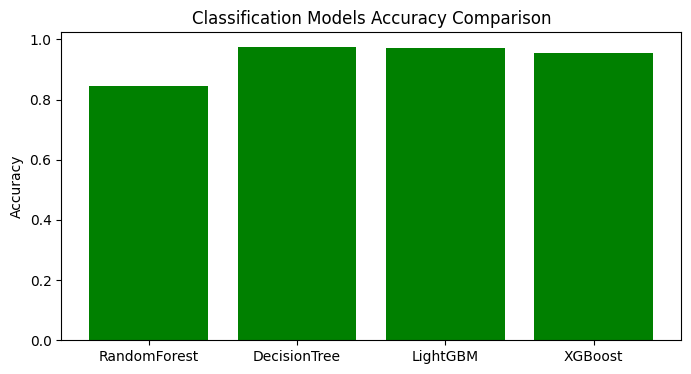

Best classification model: DecisionTree saved as Models/best_classification_model.pkl
Predicted deficiencies saved to C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\Models_resulted_prediction_dataset/predicted_deficiencies_by_classification_complete.csv


In [27]:
# Fit and save LabelEncoder on valid targets (deficiency names)
le = LabelEncoder()
le.fit(valid_targets)
joblib.dump(le, r'C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/deficiency_feature_labelencoder.pkl')
print("Label encoder saved to Models/deficiency_feature_labelencoder.pkl")

# Classification models definition
clf_models = {
    'RandomForest': MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    'DecisionTree': MultiOutputClassifier(DecisionTreeClassifier(random_state=42)),
    'LightGBM': MultiOutputClassifier(LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=-1)),
    'XGBoost': MultiOutputClassifier(XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, verbosity=0)),
}

clf_accuracies = {}

# Train each model and save
for name, model in clf_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_valid)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_valid, y_pred)
    clf_accuracies[name] = acc
    model_path = f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{name}_classification_model.pkl"
    joblib.dump(model, model_path)
    print(f"{name} accuracy: {acc:.4f}. Model saved to {model_path}")

# Plot accuracies
plt.figure(figsize=(8,4))
plt.bar(clf_accuracies.keys(), clf_accuracies.values(), color='green')
plt.title('Classification Models Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

# Select best model
best_clf_name = max(clf_accuracies, key=clf_accuracies.get)
best_clf_model = joblib.load(f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{best_clf_name}_classification_model.pkl")
joblib.dump(best_clf_model, r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/best_classification_model.pkl")
print(f"Best classification model: {best_clf_name} saved as Models/best_classification_model.pkl")

# Make predictions on test for valid targets
y_pred_valid = best_clf_model.predict(X_test)
y_pred_valid_df = pd.DataFrame(y_pred_valid, columns=valid_targets, index=y_test.index)

# Fill excluded targets with 0 to keep output shape consistent
for col in excluded_targets:
    y_pred_valid_df[col] = 0

# Reorder columns to original order
y_pred_df = y_pred_valid_df[TARGET_COLS]

# Save the complete predictions
predictions_path = r'C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\Models_resulted_prediction_dataset/predicted_deficiencies_by_classification_complete.csv'
y_pred_df.to_csv(predictions_path, index=False)
print(f"Predicted deficiencies saved to {predictions_path}")


<>:19: SyntaxWarning: invalid escape sequence '\M'
<>:31: SyntaxWarning: invalid escape sequence '\M'
<>:32: SyntaxWarning: invalid escape sequence '\M'
<>:48: SyntaxWarning: invalid escape sequence '\M'
<>:19: SyntaxWarning: invalid escape sequence '\M'
<>:31: SyntaxWarning: invalid escape sequence '\M'
<>:32: SyntaxWarning: invalid escape sequence '\M'
<>:48: SyntaxWarning: invalid escape sequence '\M'
C:\Users\mrran\AppData\Local\Temp\ipykernel_24380\3032343872.py:19: SyntaxWarning: invalid escape sequence '\M'
  joblib.dump(model, f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{name.lower()}_regressor.pkl")
C:\Users\mrran\AppData\Local\Temp\ipykernel_24380\3032343872.py:31: SyntaxWarning: invalid escape sequence '\M'
  best_regressor = joblib.load(f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{best_regressor_name.lower()}_regressor.pkl")
C:\Users\mrran\AppData\Local\Temp\ipykernel_24380\3032343872.py:32: SyntaxWarning: invalid escape sequence '\M'
  j

Training RandomForest...
RandomForest mean R^2 score: 0.9098
Training DecisionTree...
DecisionTree mean R^2 score: 0.9166
Training LightGBM...
LightGBM mean R^2 score: 0.8892
Training XGBoost...
XGBoost mean R^2 score: 0.9190


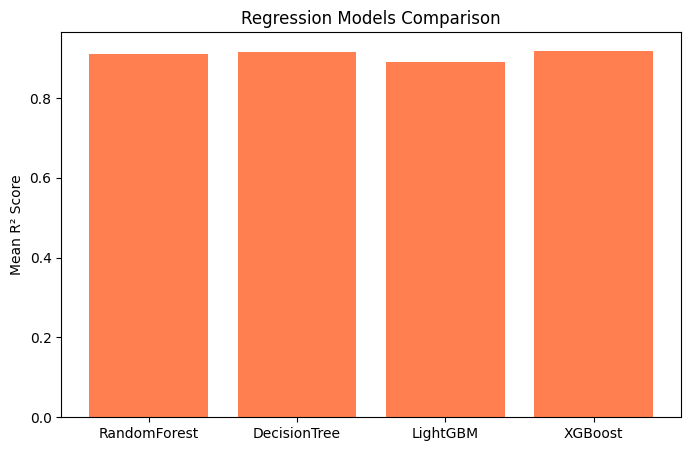

Best regressor: XGBoost with Mean R² = 0.9190


In [26]:
regressors = {
    'RandomForest': MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    'DecisionTree': MultiOutputRegressor(DecisionTreeRegressor(random_state=42)),
    'LightGBM': MultiOutputRegressor(LGBMRegressor(n_estimators=100, random_state=42)),
    'XGBoost': MultiOutputRegressor(XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
}

regression_scores = {}

for name, model in regressors.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_valid)
    preds = model.predict(X_test)
    # Calculate mean R^2 across all valid targets
    r2s = [r2_score(y_test_valid.iloc[:, i], preds[:, i]) for i in range(len(valid_targets))]
    mean_r2 = np.mean(r2s)
    regression_scores[name] = mean_r2
    # Save model
    joblib.dump(model, f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{name.lower()}_regressor.pkl")
    print(f"{name} mean R^2 score: {mean_r2:.4f}")

# Plot model comparisons
plt.figure(figsize=(8,5))
plt.bar(regression_scores.keys(), regression_scores.values(), color='coral')
plt.ylabel('Mean R² Score')
plt.title('Regression Models Comparison')
plt.show()

# Find best regressor and save it
best_regressor_name = max(regression_scores, key=regression_scores.get)
best_regressor = joblib.load(f"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/{best_regressor_name.lower()}_regressor.pkl")
joblib.dump(best_regressor, "C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/best_regressor_model.pkl")
print(f"Best regressor: {best_regressor_name} with Mean R² = {regression_scores[best_regressor_name]:.4f}")

# Predict with best regressor on test set
y_pred_valid = best_regressor.predict(X_test)
y_pred_valid_df = pd.DataFrame(y_pred_valid, columns=valid_targets, index=y_test.index)

# Fill excluded target predictions with constant values from training set (e.g., mean or mode 0)
for col in excluded_targets:
    fill_value = y_train[col].iloc[0] if y_train[col].nunique() == 1 else 0
    y_pred_valid_df[col] = fill_value

# Reorder columns to original target order
y_pred_final = y_pred_valid_df[y_train.columns]

# Save complete predictions with all targets (valid + filled)
y_pred_final.to_csv("C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\Models_resulted_prediction_dataset/predicted_deficiency_counts_by_regressor_complete.csv", index=False)

In [15]:
# Load dataset to get all target columns
df = pd.read_csv(r'C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\Final_Nutrition_Dataset.csv')
TARGET_COLS = [col for col in df.columns if col.endswith('_Deficiency')]

# Load y_train from prepared data (or load your training targets)
# For example:
# y_train = pd.read_csv('your_training_targets.csv')

valid_targets = []
excluded_targets = []
for col in y_train.columns:
    if y_train[col].nunique() > 1:
        valid_targets.append(col)
    else:
        excluded_targets.append(col)


In [21]:
from sklearn.metrics import f1_score

# Load models
best_clf = joblib.load(r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/best_classification_model.pkl")
best_reg = joblib.load(r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Models/best_regressor_model.pkl")

# Ensure you have these from your training scripts:
# valid_targets = [...]         # Targets the models were actually trained on
# excluded_targets = [...]      # Excluded constant or empty targets
# TARGET_COLS = [...]           # All original target column names (full output order)
# X_test, y_test                # Your test-set inputs and full target DataFrame

# ---- Classification predictions (already 0/1) ----
y_pred_clf = best_clf.predict(X_test)
y_pred_clf_df = pd.DataFrame(y_pred_clf, columns=valid_targets, index=y_test.index)
for col in excluded_targets:
    y_pred_clf_df[col] = 0
y_pred_clf_df = y_pred_clf_df[TARGET_COLS]

# ---- Regression predictions (float; round and clip for F1) ----
y_pred_reg_proba = best_reg.predict(X_test)
y_pred_reg = np.clip(np.rint(y_pred_reg_proba), 0, 1)
y_pred_reg_df = pd.DataFrame(y_pred_reg, columns=valid_targets, index=y_test.index)
for col in excluded_targets:
    y_pred_reg_df[col] = 0
y_pred_reg_df = y_pred_reg_df[TARGET_COLS]

# ---- Compute Macro F1 scores ----
# Ensure dtype is integer
y_true = y_test.values.astype(int)
y_pred_clf_int = y_pred_clf_df.values.astype(int)
y_pred_reg_int = y_pred_reg_df.values.astype(int)

f1_clf = f1_score(y_true, y_pred_clf_int, average='macro')
f1_reg = f1_score(y_true, y_pred_reg_int, average='macro')

print(f"Classification model Macro F1: {f1_clf:.4f}")
print(f"Regression model Macro F1: {f1_reg:.4f}")

# ---- Save the overall best model ----
if f1_clf >= f1_reg:
    print("Selected FINAL BEST MODEL: Classification")
else:
    print("Selected FINAL BEST MODEL: Regression")


print("GOT XGBOOST_REGRESSOR AS FINAL MODEL BUT CONSIDERING OTHER FACATORS LIKE *interpretable mapping*, *Binary targets* AND FEW MORE, CHOOSING DECISION_TREE_CLASSIFIER AS BEST MODEL TO BE USED")


Classification model Macro F1: 0.9234
Regression model Macro F1: 0.9244
Selected FINAL BEST MODEL: Regression
GOT XGBOOST_REGRESSOR AS FINAL MODEL BUT CONSIDERING OTHER FACATORS LIKE *interpretable mapping*, *Binary targets* AND FEW MORE, CHOOSING DECISION_TREE_CLASSIFIER AS BEST MODEL TO BE USED


c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mrran\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
